# **1. Setup & Libraries**

In [ ]:
!pip install matplotlib-scalebar
!pip install contextily

# For post-hoc seasonal tests
!pip install scikit-posthocs

!pip install pymannkendall


In [ ]:
!pip install torch torch-geometric torch-scatter torch-sparse

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=664632 sha256=bc334ca2d43c4c059c094fa918c2135ba889785b7337b19731dc1607211b8c51
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1222874 sha256=26cccd9904eca313c2ddb51f41188e6fb66d47cef1a08b64314010640699ddb8
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
Successfully built torch-scatte

In [ ]:
import torch
print(torch.__version__)


2.6.0+cpu


In [ ]:
!nvidia-smi


Mon Jan 26 21:06:01 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 461.33       Driver Version: 461.33       CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  GeForce GTX 166... WDDM  | 00000000:01:00.0  On |                  N/A |
| 25%   37C    P8    20W / 125W |    585MiB /  6144MiB |      2%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
import torch, platform, psutil, subprocess, re

print("=== SYSTEM INFO ===")
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)
print("cuDNN:", torch.backends.cudnn.version())

print("\n=== CPU INFO ===")
cpu_info = subprocess.check_output("lscpu", shell=True).decode()
print("\n".join(cpu_info.split("\n")[0:8]))

print("\n=== RAM ===")
print(f"Total: {round(psutil.virtual_memory().total/1e9,2)} GB")



=== SYSTEM INFO ===
Python: 3.11.3
PyTorch: 2.6.0+cpu
CUDA Available: False
CUDA Version: None
cuDNN: None

=== CPU INFO ===


CalledProcessError: Command 'lscpu' returned non-zero exit status 1.

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


CUDA available: False
Number of GPUs: 0
Using CPU


In [ ]:
import os
import glob
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns

from scipy.stats import mannwhitneyu, kruskal, wilcoxon
import pymannkendall as mk
import scikit_posthocs as sp


# **2. Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Rainfall/Data/Final processed 3-hourly rainfall data.csv'
df_rain = pd.read_csv(file_path)
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116614,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2116615,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2116616,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2116617,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


In [ ]:
# REMOVE THE LATE STATION (Example ID: 10325)
# Replace 10325 with the actual ID of the 2008 station
stations_to_drop = [11921]
df_rain = df_rain[~df_rain["StationID"].isin(stations_to_drop)].reset_index(drop=True)
df_rain


,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069862,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2069863,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2069864,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2069865,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


# **Hyperparameter Training**

In [ ]:
# ============================================================
# BASELINE: TemporalOnly (Transformer-only, NO graph)
# + Hyperparameter Tuning (resume-safe, fixed-per-trial hp)
#
# Output heads:
#   - Probabilistic rainfall (quantiles) for H_out steps (log1p space)
#   - 3 risk heads: flash / peak24 / acc24
#
# Composite objective (lower is better):
#   composite = 0.5*norm(CRPS_log) + 0.5*norm(mean_brier)
#
# Usage:
#   1) Load df_rain before running:
#        df_rain = pd.read_csv(".../df_rain.csv")
#   2) Tuning:
#        results_df, best = tune_temporal_only(df_rain, n_trials=10, base_seed=42)
# ============================================================

import os, json, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 0.5) Mount Google Drive (Colab)
# ============================================================
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not running in Colab or mount failed).")

SAVE_DIR = r"C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Tuning_v1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving to:", SAVE_DIR)

# ============================================================
# 1) Utilities
# ============================================================
class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    """
    probs, y_true, mask: 1D numpy arrays
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled = scaler.transform(X_flat).reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n] = 1 if all H_out future steps observed.
    """
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================
def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y    = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level) — uses your Season column
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
    }

# ============================================================
# 3) Dataset (missingness-aware)
# ============================================================
class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x  = self.X_scaled[t-self.T_in+1:t+1]     # [T_in,N,F]
        m  = self.M_in[t-self.T_in+1:t+1]         # [T_in,N,F]
        tf = self.time_feats[t-self.T_in+1:t+1]   # [T_in,N,4]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)  # [T_in,N,F+F+4]

        y  = self.Y_rain[t+1:t+1+self.H_out]       # [H_out,N]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24 from precomputed Acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),                         # x
            torch.tensor(regime_id, dtype=torch.long),       # regime
            torch.from_numpy(y_log),                         # y_log
            torch.from_numpy(my),                            # my
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24),  torch.from_numpy(macc),
        )

# ============================================================
# 4) Model: TemporalOnly Transformer
# ============================================================
class TemporalOnlyTransformer(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        """
        B, T, N, Fin = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        g = h_last + reg

        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)
        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Train/Eval
# ============================================================
def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, optimizer, quantiles, weights):
    model.train()
    total = 0.0
    nb = 0
    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg)

        # quantile loss (log space)
        q_losses = [pinball_loss(q_hat[..., k], y_log, qv, mask=my) for k, qv in enumerate(quantiles)]
        loss_q = torch.stack(q_losses).mean()

        # risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # crossing penalty (no sorting)
        q10 = q_hat[..., 0]
        q50 = q_hat[..., 1] if q_hat.size(-1) > 1 else q10
        q90 = q_hat[..., 2] if q_hat.size(-1) > 2 else q50
        phys_pen = (F.relu(q10 - q50) + F.relu(q50 - q90))
        phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak +
            weights["lambda_acc"]   * loss_acc +
            weights["lambda_phys"]  * phys_pen
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1
    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, quantiles, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE by lead using q50
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm  += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out

# ============================================================
# 6) Build data objects
# ============================================================
def build_data_objects(df_rain, T_in=16, H_out=8, train_frac=0.7, val_frac=0.15):
    prep = prepare_full_grid(df_rain)
    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=H_out)
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=T_in, H_out=H_out
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=T_in, H_out=H_out
    )
    ds_test = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=val_end, t_end=T,
        T_in=T_in, H_out=H_out
    )

    return prep, scaler, (thr3h, thrAcc24), (Acc24, MaskAcc24), (train_end, val_end, T), (ds_train, ds_val, ds_test)


def make_loaders(ds_train, ds_val, ds_test, batch_size=32):
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def infer_input_dim(train_loader):
    x0, *_ = next(iter(train_loader))
    return x0.shape[-1]

# ============================================================
# 7) Single run (final training)
# ============================================================
def run_temporal_only(
    df_rain,
    T_in=16,
    H_out=8,
    quantiles=(0.1,0.5,0.9),
    train_frac=0.7,
    val_frac=0.15,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=10,
    d_model=96,
    n_heads=4,
    num_temporal_layers=2,
    dropout=0.1,
    lambda_q=1.0,
    lambda_flash=2.0,
    lambda_peak=2.0,
    lambda_acc=2.0,
    lambda_phys=0.2,
    seed=42
):
    set_seed(seed, deterministic=False)

    prep, scaler, (thr3h, thrAcc24), (Acc24, MaskAcc24), splits, datasets = build_data_objects(
        df_rain, T_in=T_in, H_out=H_out, train_frac=train_frac, val_frac=val_frac
    )
    ds_train, ds_val, ds_test = datasets
    train_loader, val_loader, test_loader = make_loaders(ds_train, ds_val, ds_test, batch_size=batch_size)

    F_in = infer_input_dim(train_loader)
    N = len(prep["stations"])

    # pos weights from train loader only
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model = TemporalOnlyTransformer(
        num_stations=N,
        in_features=F_in,
        T_in=T_in,
        H_out=H_out,
        num_seasons=len(prep["unique_seasons"]),
        quantiles=quantiles,
        d_model=d_model,
        n_heads=n_heads,
        num_temporal_layers=num_temporal_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    weights = {
        "lambda_q": lambda_q,
        "lambda_flash": lambda_flash,
        "lambda_peak":  lambda_peak,
        "lambda_acc":   lambda_acc,
        "lambda_phys":  lambda_phys,
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, quantiles, weights)
        val_scores = evaluate(model, val_loader, quantiles)
        val_key = float(val_scores["CRPS_log"])

        if val_key < best_val:
            best_val = val_key
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {ep:02d} | train={tr_loss:.4f} | "
            f"val_CRPS_log={val_scores['CRPS_log']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f} "
            f"{'BEST' if val_key == best_val else ''}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_scores = evaluate(model, test_loader, quantiles)
    return model, prep, scaler, (thr3h, thrAcc24), test_scores

# ============================================================
# 8) Hyperparameter Tuning (resume-safe)
# ============================================================
def build_model_and_optimizer_from_hp(hp, N, F_in, num_seasons):
    model = TemporalOnlyTransformer(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=num_seasons,
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        n_heads=hp["n_heads"],
        num_temporal_layers=hp["num_temporal_layers"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
    return model, optimizer


def sample_hparams(rng):
    H_out = 8  # fixed 24h = 8×3h
    d_model = int(rng.choice([32,64, 96]))
    n_heads_candidates = [h for h in [2, 4, 8] if d_model % h == 0]
    n_heads = int(rng.choice(n_heads_candidates))

    hp = {
        "T_in": int(rng.choice([16, 24])),
        "H_out": H_out,

        "d_model": d_model,
        "n_heads": n_heads,
        "num_temporal_layers": int(rng.choice([1, 2])),
        "dropout": float(rng.choice([0.1, 0.2, 0.3])),

        "lr": float(rng.choice([5e-4, 1e-3, 2e-3])),
        "weight_decay": float(rng.choice([1e-5, 1e-4])),

        "lambda_q": 1.0,
        "lambda_flash": 2.0,
        "lambda_peak": 2.0,
        "lambda_acc": 2.0,
        "lambda_phys": float(rng.choice([0.0, 0.1, 0.25])),

        "batch_size": int(rng.choice([8, 16])),
        "epochs": 10,

        "quantiles": (0.1, 0.5, 0.9),
    }

    # safety: very heavy combo
    if hp["T_in"] == 32 and hp["d_model"] == 128:
        hp["batch_size"] = int(min(hp["batch_size"], 16))
    return hp


def run_one_trial(df_rain, trial_id, hp, trial_dir, base_seed=42):
    set_seed(base_seed + trial_id, deterministic=False)

    # data objects depend on T_in/H_out
    prep, scaler, (thr3h, thrAcc24), (Acc24, MaskAcc24), splits, datasets = build_data_objects(
        df_rain, T_in=hp["T_in"], H_out=hp["H_out"], train_frac=0.7, val_frac=0.15
    )
    ds_train, ds_val, _ = datasets

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=hp["batch_size"], shuffle=False)

    F_in = infer_input_dim(train_loader)
    N = len(prep["stations"])
    num_seasons = len(prep["unique_seasons"])

    # pos weights from TRAIN only
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model, optimizer = build_model_and_optimizer_from_hp(hp, N=N, F_in=F_in, num_seasons=num_seasons)

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    trial_log = []

    for ep in range(1, hp["epochs"] + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, hp["quantiles"], weights)
        val_scores = evaluate(model, val_loader, hp["quantiles"])

        val_key = float(val_scores["CRPS_log"])
        trial_log.append({
            "trial": trial_id,
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
        })

        print(f"[Trial {trial_id:02d}] Epoch {ep:02d} | train={tr_loss:.4f} | val_CRPS_log={val_key:.4f}")

        if val_key < best_val:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # save artifacts
    ckpt_path = os.path.join(trial_dir, "best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
    }, ckpt_path)

    pd.DataFrame(trial_log).to_csv(os.path.join(trial_dir, "epoch_log.csv"), index=False)

    return {
        "trial": int(trial_id),
        "best_val_CRPS_log": float(best_val),
        "best_epoch": int(best_epoch),
        "ckpt_path": ckpt_path,
        "val_Brier_flash": float(best_metrics["Brier_flash"]) if best_metrics is not None else np.nan,
        "val_Brier_peak":  float(best_metrics["Brier_peak"])  if best_metrics is not None else np.nan,
        "val_Brier_acc":   float(best_metrics["Brier_acc"])   if best_metrics is not None else np.nan,
        **hp
    }


def tune_temporal_only(df_rain, n_trials=10, base_seed=42):
    rng = np.random.RandomState(base_seed)

    summary_path = os.path.join(SAVE_DIR, "tuning_summary.csv")
    all_results = []

    # resume
    if os.path.exists(summary_path):
        try:
            existing = pd.read_csv(summary_path)
            if len(existing) > 0 and "trial" in existing.columns:
                all_results = existing.to_dict("records")
                print(f"✅ Resume: found {len(existing)} rows in tuning_summary.csv")
        except Exception as e:
            print("⚠️ Could not load existing summary, starting fresh:", str(e))

    for t in range(n_trials):
        trial_dir = os.path.join(SAVE_DIR, f"trial_{t:02d}")
        os.makedirs(trial_dir, exist_ok=True)

        hp_path = os.path.join(trial_dir, "hparams.json")
        ckpt_path = os.path.join(trial_dir, "best_model.pt")

        if os.path.exists(ckpt_path):
            print(f"[Trial {t:02d}] ✅ best_model.pt exists -> skipping.")
            continue

        # fixed-per-trial hparams
        if os.path.exists(hp_path):
            with open(hp_path, "r") as f:
                hp = json.load(f)
            print(f"\n[Trial {t:02d}] ✅ Reusing saved hyperparameters: {hp_path}")
        else:
            hp = sample_hparams(rng)
            with open(hp_path, "w") as f:
                json.dump(hp, f, indent=2)
            print(f"\n[Trial {t:02d}] 💾 Sampled+saved hyperparameters: {hp_path}")

        print("\n" + "="*80)
        print(f"Starting Trial {t:02d} with hparams:\n{hp}")
        print("="*80)

        try:
            res = run_one_trial(df_rain, trial_id=t, hp=hp, trial_dir=trial_dir, base_seed=base_seed)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"[Trial {t:02d}] CUDA OOM -> skipping (hp kept).")
                torch.cuda.empty_cache()
                continue
            raise e

        all_results.append(res)
        pd.DataFrame(all_results).to_csv(summary_path, index=False)

    # load final summary
    results_df = pd.read_csv(summary_path) if os.path.exists(summary_path) else pd.DataFrame(all_results)
    if len(results_df) == 0:
        raise RuntimeError("No successful trials completed.")

    # composite objective: CRPS + mean Brier
    eps = 1e-12
    results_df["mean_brier"] = (
        results_df["val_Brier_flash"].astype(float) +
        results_df["val_Brier_peak"].astype(float) +
        results_df["val_Brier_acc"].astype(float)
    ) / 3.0

    crps = results_df["best_val_CRPS_log"].astype(float)
    bri  = results_df["mean_brier"].astype(float)
    crps_n = (crps - crps.min()) / (crps.max() - crps.min() + eps)
    bri_n  = (bri  - bri.min())  / (bri.max()  - bri.min()  + eps)

    results_df["composite_obj"] = 0.5*crps_n + 0.5*bri_n
    results_df = results_df.sort_values("composite_obj", ascending=True)
    results_df.to_csv(summary_path, index=False)

    best = results_df.iloc[0].to_dict()
    with open(os.path.join(SAVE_DIR, "best_trial.json"), "w") as f:
        json.dump(best, f, indent=2)

    print("\n✅ Tuning finished.")
    print("Best trial:", int(best["trial"]))
    print("Best composite objective:", best["composite_obj"])
    print("Best val CRPS_log:", best["best_val_CRPS_log"])
    print("Best mean Brier:", best["mean_brier"])
    print("Checkpoint:", best["ckpt_path"])
    return results_df, best




Using device: cpu
Colab drive not mounted (not running in Colab or mount failed).
Saving to: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Tuning_v1


In [ ]:
# ============================================================
# 9) RUN (example)

# 1) Hyperparameter tuning:
results_df, best_trial = tune_temporal_only(df_rain, n_trials=15, base_seed=42)


✅ Resume: found 10 rows in tuning_summary.csv
[Trial 00] ✅ best_model.pt exists -> skipping.
[Trial 01] ✅ best_model.pt exists -> skipping.
[Trial 02] ✅ best_model.pt exists -> skipping.
[Trial 03] ✅ best_model.pt exists -> skipping.
[Trial 04] ✅ best_model.pt exists -> skipping.
[Trial 05] ✅ best_model.pt exists -> skipping.
[Trial 06] ✅ best_model.pt exists -> skipping.
[Trial 07] ✅ best_model.pt exists -> skipping.
[Trial 08] ✅ best_model.pt exists -> skipping.
[Trial 09] ✅ best_model.pt exists -> skipping.

[Trial 10] ✅ Reusing saved hyperparameters: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Tuning_v1\trial_10\hparams.json

Starting Trial 10 with hparams:
{'T_in': 16, 'H_out': 8, 'd_model': 96, 'n_heads': 2, 'num_temporal_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 1e-05, 'lambda_q': 1.0, 'lambda_flash': 2.0, 'lambda_peak': 2.0, 'lambda_acc': 2.0, 'lambda_phys': 0.1, 'batch_size': 8, 'epochs': 10, 'quantiles': [0.1, 0.5, 0.9]}
Total stations: 34
Total uniq

C:\Users\pc\AppData\Local\Temp\ipykernel_14608\1857864445.py:351: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 10] Epoch 01 | train=4.9821 | val_CRPS_log=0.1467


C:\Users\pc\AppData\Local\Temp\ipykernel_14608\1857864445.py:351: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 10] Epoch 02 | train=4.8544 | val_CRPS_log=0.1475


...

[Trial 14] Epoch 08 | train=4.8271 | val_CRPS_log=0.1490


C:\Users\pc\AppData\Local\Temp\ipykernel_14608\1857864445.py:351: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 09 | train=4.8261 | val_CRPS_log=0.1495


C:\Users\pc\AppData\Local\Temp\ipykernel_14608\1857864445.py:351: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 10 | train=4.8197 | val_CRPS_log=0.1524

✅ Tuning finished.
Best trial: 11
Best composite objective: 0.1097914543929452
Best val CRPS_log: 0.1424346592566095
Best mean Brier: 0.13557775415843518
Checkpoint: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Tuning_v1\trial_11\best_model.pt


# **Model Training**

In [ ]:
# ============================================================
# BASELINE: TemporalOnly Transformer
# Final Training Script (Standalone)
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Assumes best_trial.json exists (from tuning) at:
#     TUNING_SAVE_DIR/best_trial.json
# - Loads best hyperparameters from tuning
# - Trains final TemporalOnly model with:
#     * early stopping on val CRPS_log
#     * per-epoch metrics printed + logged
# - Saves to FINAL_SAVE_DIR:
#     * final_epoch_log.csv
#     * final_best_model.pt
# ============================================================

import os, json, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# (Optional) Colab mount
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not in Colab or mount failed).")

# ============================================================
# 0.5) Paths (EDIT THESE AS NEEDED)
# ============================================================

# For local PC (your earlier tuning path):
TUNING_SAVE_DIR = r"C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Tuning_v1"
FINAL_SAVE_DIR  = r"C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Final_Run\v1"

os.makedirs(TUNING_SAVE_DIR, exist_ok=True)
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)

print("Tuning directory:", TUNING_SAVE_DIR)
print("Final run artifacts will be saved to:", FINAL_SAVE_DIR)

# ============================================================
# 1) Utilities (same as tuning)
# ============================================================

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled = scaler.transform(X_flat).reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y    = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
    }

# ============================================================
# 3) Dataset (same as tuning)
# ============================================================

class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x  = self.X_scaled[t-self.T_in+1:t+1]     # [T_in,N,F]
        m  = self.M_in[t-self.T_in+1:t+1]         # [T_in,N,F]
        tf = self.time_feats[t-self.T_in+1:t+1]   # [T_in,N,4]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)  # [T_in,N,F+F+4]

        y  = self.Y_rain[t+1:t+1+self.H_out]       # [H_out,N]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24 from precomputed Acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),                         # x
            torch.tensor(regime_id, dtype=torch.long),       # regime
            torch.from_numpy(y_log),                         # y_log
            torch.from_numpy(my),                            # my
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24),  torch.from_numpy(macc),
        )

# ============================================================
# 4) Model: TemporalOnly Transformer (same as tuning)
# ============================================================

class TemporalOnlyTransformer(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        """
        B, T, N, Fin = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        g = h_last + reg

        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)
        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Train / Eval (same as tuning)
# ============================================================

def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, optimizer, quantiles, weights):
    model.train()
    total = 0.0
    nb = 0
    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg)

        # quantile loss (log space)
        q_losses = [pinball_loss(q_hat[..., k], y_log, qv, mask=my) for k, qv in enumerate(quantiles)]
        loss_q = torch.stack(q_losses).mean()

        # risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # crossing penalty (no sorting)
        q10 = q_hat[..., 0]
        q50 = q_hat[..., 1] if q_hat.size(-1) > 1 else q10
        q90 = q_hat[..., 2] if q_hat.size(-1) > 2 else q50
        phys_pen = (F.relu(q10 - q50) + F.relu(q50 - q90))
        phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak  +
            weights["lambda_acc"]   * loss_acc   +
            weights["lambda_phys"]  * phys_pen
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1
    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, quantiles, thresholds=(0.1,0.2,0.3,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm  += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log":   total_crps_log / max(nb, 1),
        "CRPS_mm":    total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out

# ============================================================
# 6) Build data objects (same as tuning)
# ============================================================

def build_data_objects(df_rain, T_in=16, H_out=8, train_frac=0.7, val_frac=0.15):
    prep = prepare_full_grid(df_rain)
    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=H_out)
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=T_in, H_out=H_out
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=T_in, H_out=H_out
    )
    ds_test = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=val_end, t_end=T,
        T_in=T_in, H_out=H_out
    )

    return prep, scaler, (thr3h, thrAcc24), (Acc24, MaskAcc24), (train_end, val_end, T), (ds_train, ds_val, ds_test)


def make_loaders(ds_train, ds_val, ds_test, batch_size=32):
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def infer_input_dim(train_loader):
    x0, *_ = next(iter(train_loader))
    return x0.shape[-1]

# ============================================================
# 7) Load best hparams from tuning (best_trial.json)
# ============================================================

def load_best_hparams(best_trial_path):
    with open(best_trial_path, "r") as f:
        best = json.load(f)

    raw_q = best.get("quantiles", [0.1, 0.5, 0.9])

    if isinstance(raw_q, str):
        # e.g. "(0.1, 0.5, 0.9)" or "[0.1, 0.5, 0.9]"
        parts = raw_q.strip("()[]").split(",")
        qs = [float(p.strip()) for p in parts if p.strip() != ""]
        quantiles = tuple(qs)
    else:
        quantiles = tuple(float(q) for q in raw_q)

    hp = {
        "T_in":         16,
        "H_out":        8,
        "d_model":      96,
        "n_heads":      2,
        "num_layers":   1,
        "dropout":      0.1,
        "lr":           5e-4,
        "weight_decay": 1e-5,
        "lambda_q":     1.0,
        "lambda_flash": 2.0,
        "lambda_peak":  2.0,
        "lambda_acc":   2.0,
        "lambda_phys":  0.1,
        "batch_size":   8,
        "quantiles":    quantiles,
    }
    return hp



# ============================================================
# 8) Final training with early stopping (TemporalOnly)
# ============================================================

def final_train_temporalonly(df_rain,
                             hp,
                             final_save_dir=FINAL_SAVE_DIR,
                             train_frac=0.7,
                             val_frac=0.15,
                             base_seed=42,
                             max_epochs=None,
                             patience=5):
    """
    Final training run with fixed hyperparameters (hp) for TemporalOnly Transformer.
    - Early stopping on val CRPS_log
    - Saves:
        * final_best_model.pt
        * final_epoch_log.csv
    """
    if max_epochs is None:
        max_epochs = hp["epochs"]

    set_seed(base_seed, deterministic=False)

    # Build data objects with SAME pipeline as tuning
    prep, scaler, (thr3h, thrAcc24), (Acc24, MaskAcc24), splits, datasets = build_data_objects(
        df_rain,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        train_frac=train_frac,
        val_frac=val_frac,
    )
    train_end, val_end, T_total = splits
    ds_train, ds_val, ds_test = datasets
    train_loader, val_loader, _ = make_loaders(
        ds_train, ds_val, ds_test, batch_size=hp["batch_size"]
    )

    F_in = infer_input_dim(train_loader)
    N = len(prep["stations"])
    num_seasons = len(prep["unique_seasons"])

    # pos weights from TRAIN only
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model = TemporalOnlyTransformer(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=num_seasons,
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        n_heads=hp["n_heads"],
        num_temporal_layers=hp["num_layers"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    weights = {
        "lambda_q":     hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash":  pos_w_flash,
        "pos_w_peak":   pos_w_peak,
        "pos_w_acc":    pos_w_acc,
    }

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    epoch_log = []
    epochs_since_improve = 0

    for ep in range(1, max_epochs + 1):
        tr_loss = train_one_epoch(
            model, train_loader, optimizer,
            quantiles=hp["quantiles"], weights=weights
        )
        val_scores = evaluate(
            model, val_loader,
            quantiles=hp["quantiles"]
        )

        val_key = float(val_scores["CRPS_log"])

        row = {
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
        }
        epoch_log.append(row)

        print(
            f"[FINAL TemporalOnly] Epoch {ep:02d} | "
            f"train={tr_loss:.4f} | "
            f"val_CRPS_log={val_key:.4f} | "
            f"val_CRPS_mm={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f}"
        )

        if val_key < best_val - 1e-6:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
            print(f"   -> New best epoch {ep:02d} (val_CRPS_log={best_val:.4f})")
        else:
            epochs_since_improve += 1
            print(f"   -> No improvement for {epochs_since_improve} epoch(s)")

        log_path = os.path.join(final_save_dir, "final_epoch_log.csv")
        pd.DataFrame(epoch_log).to_csv(log_path, index=False)

        if epochs_since_improve >= patience:
            print(f"\n[EARLY STOP] No improvement in {patience} epochs. Stopping at epoch {ep}.")
            break

    ckpt_path = os.path.join(final_save_dir, "final_best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
        "thr3h": thr3h,
        "thrAcc24": thrAcc24,
        "stations": prep["stations"],
        "times": prep["times"],
        "train_frac": float(train_frac),
        "val_frac": float(val_frac),
    }, ckpt_path)

    print("\n[FINAL TemporalOnly] Training finished.")
    print("Best epoch:", best_epoch, "| best val CRPS_log:", best_val)
    print("Checkpoint saved to:", ckpt_path)
    print("Epoch log saved to:", log_path)

    return {
        "best_epoch": best_epoch,
        "best_val_CRPS_log": best_val,
        "ckpt_path": ckpt_path,
        "log_path": log_path,
        "hp": hp,
    }

best_trial_path = os.path.join(TUNING_SAVE_DIR, "best_trial.json")
best_hp = load_best_hparams(best_trial_path)

# Optionally override final epochs:
best_hp["epochs"] = 50  # e.g. allow up to 50 epochs in final run

final_results = final_train_temporalonly(
    df_rain=df_rain,
    hp=best_hp,
    final_save_dir=FINAL_SAVE_DIR,
    train_frac=0.7,
    val_frac=0.15,
    base_seed=42,
    max_epochs=best_hp["epochs"],
    patience=10,
)

print("\nFinal TemporalOnly results summary:")
print(final_results)


Using device: cpu
Colab drive not mounted (not in Colab or mount failed).
Tuning directory: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Tuning_v1
Final run artifacts will be saved to: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Final_Run\v1
Total stations: 34
Total unique times: 61360


C:\Users\pc\AppData\Local\Temp\ipykernel_21324\2215062005.py:353: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL TemporalOnly] Epoch 01 | train=4.9780 | val_CRPS_log=0.1468 | val_CRPS_mm=0.7217 | val_BS_flash=0.1911 | val_BS_peak=0.1763 | val_BS_acc=0.1899
   -> New best epoch 01 (val_CRPS_log=0.1468)


C:\Users\pc\AppData\Local\Temp\ipykernel_21324\2215062005.py:353: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL TemporalOnly] Epoch 02 | train=4.8452 | val_CRPS_log=0.1467 | val_CRPS_mm=0.7210 | val_BS_flash=0.1274 | val_BS_peak=0.1639 | val_BS_acc=0.1480
   -> New best epoch 02 (val_CRPS_log=0.1467)


...

[FINAL TemporalOnly] Epoch 25 | train=4.6412 | val_CRPS_log=0.1421 | val_CRPS_mm=0.7148 | val_BS_flash=0.1579 | val_BS_peak=0.1703 | val_BS_acc=0.1681
   -> No improvement for 8 epoch(s)


C:\Users\pc\AppData\Local\Temp\ipykernel_21324\2215062005.py:353: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL TemporalOnly] Epoch 26 | train=4.6345 | val_CRPS_log=0.1414 | val_CRPS_mm=0.7146 | val_BS_flash=0.1432 | val_BS_peak=0.1609 | val_BS_acc=0.1550
   -> No improvement for 9 epoch(s)


C:\Users\pc\AppData\Local\Temp\ipykernel_21324\2215062005.py:353: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL TemporalOnly] Epoch 27 | train=4.6302 | val_CRPS_log=0.1414 | val_CRPS_mm=0.7149 | val_BS_flash=0.1260 | val_BS_peak=0.1634 | val_BS_acc=0.1703
   -> No improvement for 10 epoch(s)

[EARLY STOP] No improvement in 10 epochs. Stopping at epoch 27.

[FINAL TemporalOnly] Training finished.
Best epoch: 17 | best val CRPS_log: 0.14132769567890333
Checkpoint saved to: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Final_Run\v1\final_best_model.pt
Epoch log saved to: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Final_Run\v1\final_epoch_log.csv

Final TemporalOnly results summary:
{'best_epoch': 17, 'best_val_CRPS_log': 0.14132769567890333, 'ckpt_path': 'C:\\Users\\pc\\Documents\\Rainfall\\Baselines\\TemporalOnly\\Final_Run\\v1\\final_best_model.pt', 'log_path': 'C:\\Users\\pc\\Documents\\Rainfall\\Baselines\\TemporalOnly\\Final_Run\\v1\\final_epoch_log.csv', 'hp': {'T_in': 16, 'H_out': 8, 'd_model': 96, 'n_heads': 2, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'weight

# Testing

Using device: cpu
Colab drive not mounted (not in Colab or mount failed).
Checkpoint path: C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Final_Run\v1\final_best_model.pt
Log path       : C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Final_Run\v1\final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1413
  best_epoch       : 17
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9181
Input feature dim: 18

Model rebuilt and weights loaded.


C:\Users\pc\AppData\Local\Temp\ipykernel_21324\680173823.py:326: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



========== TEMPORALONLY TEST METRICS ==========
CRPS_log   : 0.1195
CRPS_mm    : 0.6088
Brier_flash: 0.1222
Brier_peak : 0.1536
Brier_acc  : 0.1454

[Flash 3h]  PR-AUC=0.3478, ROC-AUC=0.8927, n_valid=307503
[Peak24]   PR-AUC=0.5704, ROC-AUC=0.8637, n_valid=307535
[Acc24]    PR-AUC=0.2258, ROC-AUC=0.8608, n_valid=307195

Loaded epoch log with 27 rows.


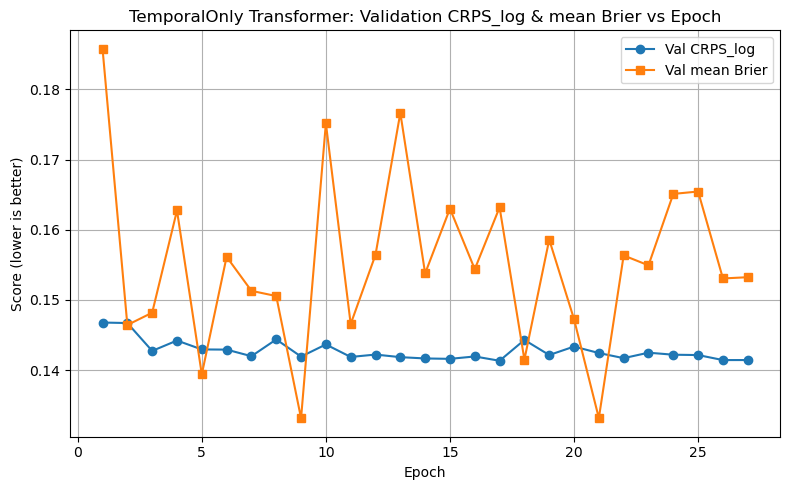

In [ ]:
# ============================================================
# BASELINE: TemporalOnly Transformer
# Standalone TESTING Script
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Assumes final_best_model.pt exists at:
#     FINAL_SAVE_DIR/final_best_model.pt
# - Reloads best hyperparameters + weights
# - Rebuilds preprocessing and TEST set
# - Evaluates on TEST split (no retraining)
# - Optionally plots validation metrics vs epoch
# ============================================================

import os, json, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# ============================================================
# 0) Reproducibility + Device
# ============================================================

def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# (Optional) Colab mount
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not in Colab or mount failed).")

# ============================================================
# 0.5) Paths (EDIT THESE AS NEEDED)
# ============================================================

# For your local PC (consistent with training script):
FINAL_SAVE_DIR = r"C:\Users\pc\Documents\Rainfall\Baselines\TemporalOnly\Final_Run\v1"

CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ============================================================
# 1) Utilities (same as training)
# ============================================================

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        # Robust even if std_ is very small
        std_safe = np.where(self.std_ < self.eps, 1.0, self.std_)
        return (X - self.mean_) / std_safe


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 2) Preprocessing (FULL GRID, same as training)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y    = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin  = np.sin(2*np.pi*(hour/24.0))
    hour_cos  = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
    }

# ============================================================
# 3) Dataset (same as training)
# ============================================================

class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x  = self.X_scaled[t-self.T_in+1:t+1]     # [T_in,N,F]
        m  = self.M_in[t-self.T_in+1:t+1]         # [T_in,N,F]
        tf = self.time_feats[t-self.T_in+1:t+1]   # [T_in,N,4]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)  # [T_in,N,F+F+4]

        y  = self.Y_rain[t+1:t+1+self.H_out]       # [H_out,N]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24 from precomputed Acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),                         # x
            torch.tensor(regime_id, dtype=torch.long),       # regime
            torch.from_numpy(y_log),                         # y_log
            torch.from_numpy(my),                            # my
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24),  torch.from_numpy(macc),
        )

# ============================================================
# 4) Model: TemporalOnly Transformer (same as training)
# ============================================================

class TemporalOnlyTransformer(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        """
        B, T, N, Fin = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        g = h_last + reg

        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)
        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Evaluation (same as training)
# ============================================================

@torch.no_grad()
def evaluate(model, loader, quantiles, thresholds=(0.1,0.2,0.3,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm  += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log":   total_crps_log / max(nb, 1),
        "CRPS_mm":    total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out

# ============================================================
# 6) Load checkpoint, rebuild TEST set, evaluate
# ============================================================

# ---- 6.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
hp = ckpt["hparams"]
state_dict = ckpt["state_dict"]
thr3h = ckpt["thr3h"]
thrAcc24 = ckpt["thrAcc24"]
train_frac = float(ckpt.get("train_frac", 0.7))
val_frac   = float(ckpt.get("val_frac", 0.15))

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")


prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

T_total = len(prep["times"])
train_end, val_end = make_splits(T_total, train_frac=train_frac, val_frac=val_frac)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T_total)

# Scaling using saved scaler stats
scaler = NaNIgnoringStandardScaler()
scaler.mean_ = np.array(ckpt["scaler_mean"])
scaler.std_  = np.array(ckpt["scaler_std"])

X_raw = prep["X_raw"]
T_, N_, F_in_raw = X_raw.shape
X_flat = X_raw.reshape(T_ * N_, F_in_raw)
X_scaled_flat = scaler.transform(X_flat)
X_scaled = X_scaled_flat.reshape(T_, N_, F_in_raw).astype(np.float32)

# Acc24 + mask
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))

# Build TEST dataset only
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T_total,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(
    ds_test,
    batch_size=int(hp["batch_size"]),
    shuffle=False
)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 6.4 Rebuild model and load weights ----
model = TemporalOnlyTransformer(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_layers"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 6.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    )

print("\n========== TEMPORALONLY TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

print("\n[Flash 3h]  PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    fm["pr_auc"], fm["roc_auc"], fm["n_valid"]
))
print("[Peak24]   PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    pm["pr_auc"], pm["roc_auc"], pm["n_valid"]
))
print("[Acc24]    PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    am["pr_auc"], am["roc_auc"], am["n_valid"]
))

# ============================================================
# 7) Optional: Plot validation curves from final_epoch_log.csv
# ============================================================

if os.path.exists(LOG_PATH):
    log_df = pd.read_csv(LOG_PATH)
    print("\nLoaded epoch log with {} rows.".format(len(log_df)))

    log_df["mean_brier"] = log_df[[
        "val_Brier_flash",
        "val_Brier_peak",
        "val_Brier_acc"
    ]].mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
    plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
    plt.xlabel("Epoch")
    plt.ylabel("Score (lower is better)")
    plt.title("TemporalOnly Transformer: Validation CRPS_log & mean Brier vs Epoch")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\n(final_epoch_log.csv not found, skipping learning curve plot)")


# Wilcoxon

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint path: /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/TemporalOnly/Final_Run/v1/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/TemporalOnly/Final_Run/v1/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1413
  best_epoch       : 17
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9181
Input feature dim: 18

Model rebuilt and weights loaded.


/tmp/ipython-input-2411254211.py:326: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



Collected 1148 batches, mean CRPS_log = 0.1195
Saved scores to: /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/TemporalOnly/Final_Run/v1/temporal_scores.npy

========== TEMPORALONLY TEST METRICS ==========
CRPS_log   : 0.1195
CRPS_mm    : 0.6088
Brier_flash: 0.1222
Brier_peak : 0.1536
Brier_acc  : 0.1454

[Flash 3h]  PR-AUC=0.3478, ROC-AUC=0.8927, n_valid=307503
[Peak24]   PR-AUC=0.5704, ROC-AUC=0.8637, n_valid=307535
[Acc24]    PR-AUC=0.2258, ROC-AUC=0.8608, n_valid=307195

Loaded epoch log with 27 rows.


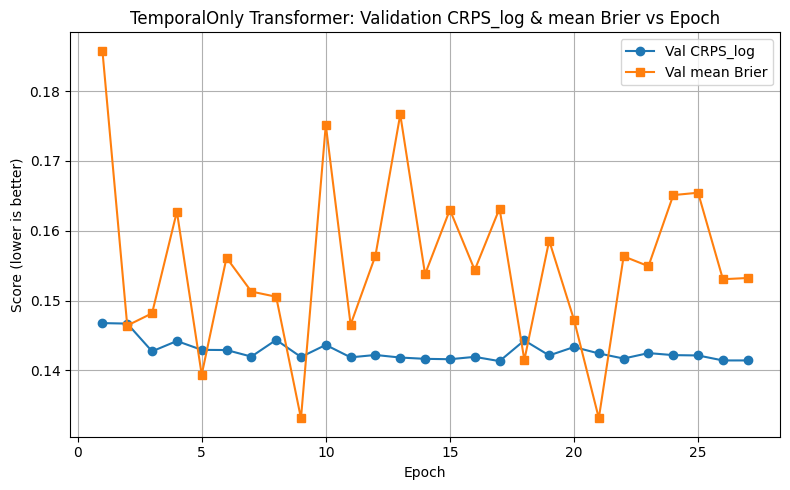

In [ ]:
# ============================================================
# BASELINE: TemporalOnly Transformer
# Standalone TESTING Script
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Assumes final_best_model.pt exists at:
#     FINAL_SAVE_DIR/final_best_model.pt
# - Reloads best hyperparameters + weights
# - Rebuilds preprocessing and TEST set
# - Evaluates on TEST split (no retraining)
# - Optionally plots validation metrics vs epoch
# ============================================================

import os, json, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# ============================================================
# 0) Reproducibility + Device
# ============================================================

def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# (Optional) Colab mount
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not in Colab or mount failed).")

# ============================================================
# 0.5) Paths (EDIT THESE AS NEEDED)
# ============================================================

# For your local PC (consistent with training script):
FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/TemporalOnly/Final_Run/v1"

CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ============================================================
# 1) Utilities (same as training)
# ============================================================

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        # Robust even if std_ is very small
        std_safe = np.where(self.std_ < self.eps, 1.0, self.std_)
        return (X - self.mean_) / std_safe


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 2) Preprocessing (FULL GRID, same as training)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y    = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin  = np.sin(2*np.pi*(hour/24.0))
    hour_cos  = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
    }

# ============================================================
# 3) Dataset (same as training)
# ============================================================

class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x  = self.X_scaled[t-self.T_in+1:t+1]     # [T_in,N,F]
        m  = self.M_in[t-self.T_in+1:t+1]         # [T_in,N,F]
        tf = self.time_feats[t-self.T_in+1:t+1]   # [T_in,N,4]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)  # [T_in,N,F+F+4]

        y  = self.Y_rain[t+1:t+1+self.H_out]       # [H_out,N]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24 from precomputed Acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),                         # x
            torch.tensor(regime_id, dtype=torch.long),       # regime
            torch.from_numpy(y_log),                         # y_log
            torch.from_numpy(my),                            # my
            torch.from_numpy(flash), torch.from_numpy(mflash),
            torch.from_numpy(peak24), torch.from_numpy(mpeak),
            torch.from_numpy(acc24),  torch.from_numpy(macc),
        )

# ============================================================
# 4) Model: TemporalOnly Transformer (same as training)
# ============================================================

class TemporalOnlyTransformer(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        """
        B, T, N, Fin = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        g = h_last + reg

        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)
        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 5) Evaluation (same as training)
# ============================================================

@torch.no_grad()
def evaluate(model, loader, quantiles, thresholds=(0.1,0.2,0.3,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm  += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log":   total_crps_log / max(nb, 1),
        "CRPS_mm":    total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out

# ============================================================
# 5b) Per-batch evaluation for Wilcoxon significance testing
# ============================================================

@torch.no_grad()
def evaluate_per_batch(model, loader, quantiles, device):
    """
    Returns per-batch CRPS_log scores for significance testing.
    Note: TemporalOnly model does NOT use edge_index.
    """
    model.eval()
    batch_crps_log = []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)

        q_hat, _, _, _ = model(x, reg)

        crps_log = crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()
        batch_crps_log.append(crps_log)

    return np.array(batch_crps_log)


# ============================================================
# 6) Load checkpoint, rebuild TEST set, evaluate
# ============================================================

# ---- 6.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
hp = ckpt["hparams"]
state_dict = ckpt["state_dict"]
thr3h = ckpt["thr3h"]
thrAcc24 = ckpt["thrAcc24"]
train_frac = float(ckpt.get("train_frac", 0.7))
val_frac   = float(ckpt.get("val_frac", 0.15))

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")


prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

T_total = len(prep["times"])
train_end, val_end = make_splits(T_total, train_frac=train_frac, val_frac=val_frac)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T_total)

# Scaling using saved scaler stats
scaler = NaNIgnoringStandardScaler()
scaler.mean_ = np.array(ckpt["scaler_mean"])
scaler.std_  = np.array(ckpt["scaler_std"])

X_raw = prep["X_raw"]
T_, N_, F_in_raw = X_raw.shape
X_flat = X_raw.reshape(T_ * N_, F_in_raw)
X_scaled_flat = scaler.transform(X_flat)
X_scaled = X_scaled_flat.reshape(T_, N_, F_in_raw).astype(np.float32)

# Acc24 + mask
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))

# Build TEST dataset only
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T_total,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(
    ds_test,
    batch_size=int(hp["batch_size"]),
    shuffle=False
)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 6.4 Rebuild model and load weights ----
model = TemporalOnlyTransformer(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_layers"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 6.5a Get per-batch scores for Wilcoxon ----
temp_scores = evaluate_per_batch(
    model, test_loader,
    quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    device=device
)
print(f"\nCollected {len(temp_scores)} batches, mean CRPS_log = {temp_scores.mean():.4f}")

# ---- 6.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    )


# ---- 6.5b Save per-batch scores for Wilcoxon ----
SAVE_DIR = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/TemporalOnly/Final_Run/v1"
os.makedirs(SAVE_DIR, exist_ok=True)
np.save(os.path.join(SAVE_DIR, "temporal_scores.npy"), temp_scores)
print(f"Saved scores to: {os.path.join(SAVE_DIR, 'temporal_scores.npy')}")

print("\n========== TEMPORALONLY TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

print("\n[Flash 3h]  PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(fm["pr_auc"], fm["roc_auc"], fm["n_valid"]))
print("[Peak24]   PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(pm["pr_auc"], pm["roc_auc"], pm["n_valid"]))
print("[Acc24]    PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(am["pr_auc"], am["roc_auc"], am["n_valid"]))

# ============================================================
# 7) Optional: Plot validation curves from final_epoch_log.csv
# ============================================================

if os.path.exists(LOG_PATH):
    log_df = pd.read_csv(LOG_PATH)
    print("\nLoaded epoch log with {} rows.".format(len(log_df)))

    log_df["mean_brier"] = log_df[[
        "val_Brier_flash",
        "val_Brier_peak",
        "val_Brier_acc"
    ]].mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
    plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
    plt.xlabel("Epoch")
    plt.ylabel("Score (lower is better)")
    plt.title("TemporalOnly Transformer: Validation CRPS_log & mean Brier vs Epoch")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\n(final_epoch_log.csv not found, skipping learning curve plot)")
